In [153]:
import pandas as pd

fake = pd.read_csv("../data/Fake.csv")
true = pd.read_csv("../data/True.csv")

fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [154]:
fake.shape

(23481, 4)

In [155]:
true.shape

(21417, 4)

In [156]:
fake["label"]=0
true["label"]=1

In [157]:
true.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


In [158]:
fake.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [159]:
data=pd.concat([fake,true])

In [160]:
data.shape

(44898, 5)

In [161]:
data.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [162]:
data=data.sample(frac=1)

In [163]:
data.head()

,title,text,subject,date,label
3864,Trump firing of FBI Director Comey evokes crit...,WASHINGTON (Reuters) - After U.S. President Do...,politicsNews,"May 10, 2017",1
9328,JUST IN: JUDICIAL WATCH Claims Comey’s FBI Hid...,Remember when President Barack Obama s Attorne...,politics,"Nov 28, 2017",0
17472,CNN’S FAKE NEWS BACKFIRES! CNN Legal Analyst A...,Hell has frozen over! CNN is actually reportin...,left-news,"Dec 28, 2017",0
18596,BREAKING NEWS: Reince Priebus Makes Early Retu...,The White House confirmed to FOX Business that...,left-news,"May 21, 2017",0
1094,"Top Senate Republican, White House, aim for ta...",WASHINGTON (Reuters) - The top U.S. Senate Rep...,politicsNews,"October 22, 2017",1


In [164]:
data=data.reset_index(drop=True)

In [165]:
data.head()

,title,text,subject,date,label
0,Trump firing of FBI Director Comey evokes crit...,WASHINGTON (Reuters) - After U.S. President Do...,politicsNews,"May 10, 2017",1
1,JUST IN: JUDICIAL WATCH Claims Comey’s FBI Hid...,Remember when President Barack Obama s Attorne...,politics,"Nov 28, 2017",0
2,CNN’S FAKE NEWS BACKFIRES! CNN Legal Analyst A...,Hell has frozen over! CNN is actually reportin...,left-news,"Dec 28, 2017",0
3,BREAKING NEWS: Reince Priebus Makes Early Retu...,The White House confirmed to FOX Business that...,left-news,"May 21, 2017",0
4,"Top Senate Republican, White House, aim for ta...",WASHINGTON (Reuters) - The top U.S. Senate Rep...,politicsNews,"October 22, 2017",1


In [166]:
#import libraries of data preprocessing /cleaning
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to C:\Users\Princy
[nltk_data]     Priya\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [167]:
def clean_text(text):
    
    text = text.lower()
    
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    
    words = text.split()
    
    words = [word for word in words if word not in stop_words]
    
    return " ".join(words)

In [168]:
data["text"] = data["text"].apply(clean_text)

In [169]:
data.head()

,title,text,subject,date,label
0,Trump firing of FBI Director Comey evokes crit...,washington reuters u president donald trump fi...,politicsNews,"May 10, 2017",1
1,JUST IN: JUDICIAL WATCH Claims Comey’s FBI Hid...,remember president barack obama attorney gener...,politics,"Nov 28, 2017",0
2,CNN’S FAKE NEWS BACKFIRES! CNN Legal Analyst A...,hell frozen cnn actually reporting truth cnn l...,left-news,"Dec 28, 2017",0
3,BREAKING NEWS: Reince Priebus Makes Early Retu...,white house confirmed fox business priebus wou...,left-news,"May 21, 2017",0
4,"Top Senate Republican, White House, aim for ta...",washington reuters top u senate republican whi...,politicsNews,"October 22, 2017",1


In [170]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [171]:
#most imp 5000 words for ranking(priority) in vectors
vectorizer = TfidfVectorizer(max_features=5000)

In [172]:
#transforming the cleaned text into vectors of numbers from 5000 ranking of words
data["content"] = data["title"] + " " + data["text"]

X = vectorizer.fit_transform(data["content"])

In [173]:
y=data["label"]

In [174]:
X.shape

(44898, 5000)

In [175]:
#train test split
from sklearn.model_selection import train_test_split

In [176]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [177]:
print(X_train.shape)
print(X_test.shape)

(35918, 5000)
(8980, 5000)


In [178]:
print(y_train.shape)
print(y_test.shape)

(35918,)
(8980,)


In [179]:
from sklearn.naive_bayes import MultinomialNB

In [180]:
#empty model ready to learn
nb_model = MultinomialNB()

In [181]:
# fit means train
nb_model.fit(X_train, y_train)

MultinomialNB()

In [182]:
y_pred = nb_model.predict(X_test)

In [183]:
y_pred[:10]

array([1, 0, 1, 0, 0, 0, 1, 0, 1, 1], dtype=int64)

In [184]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9364142538975501


In [185]:
import pandas as pd

comparison = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10]
})

comparison

,Actual,Predicted
0,1,1
1,0,0
2,1,1
3,0,0
4,0,0
5,1,0
6,1,1
7,0,0
8,1,1
9,1,1


In [186]:
from sklearn.metrics import confusion_matrix

In [187]:
cm = confusion_matrix(y_test, y_pred)

print(cm)
#[[TN FP]
# [FN TP]]

[[4374  257]
 [ 314 4035]]


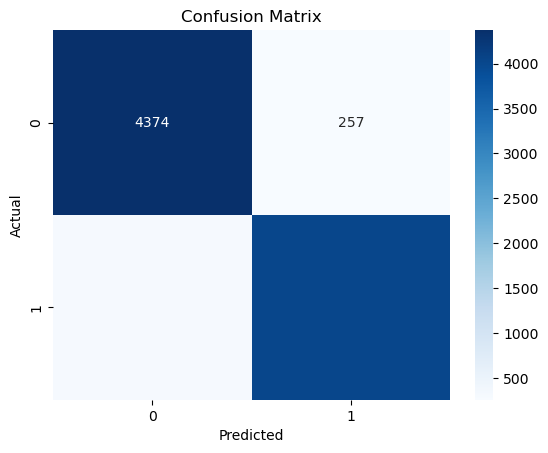

In [188]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [189]:
import pickle

pickle.dump(nb_model, open("../models/naive_bayes_model.pkl", "wb"))

In [190]:
X_train.shape
X_test.shape

(8980, 5000)

In [191]:
from sklearn.tree import DecisionTreeClassifier

In [192]:
dt_model = DecisionTreeClassifier()

In [193]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier()

In [194]:
y_pred_dt = dt_model.predict(X_test)

In [195]:
from sklearn.metrics import accuracy_score

accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)

Decision Tree Accuracy: 0.9965478841870824


In [196]:
from sklearn.metrics import confusion_matrix

cm_dt = confusion_matrix(y_test, y_pred_dt)

print(cm_dt)

[[4621   10]
 [  21 4328]]


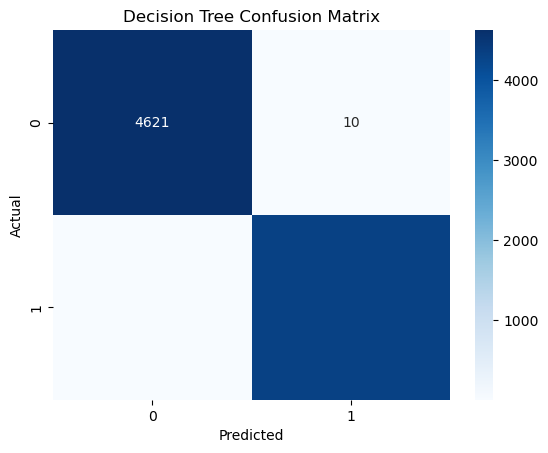

In [197]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [198]:
import pickle
pickle.dump(dt_model, open("../models/fake_news_model_decision_tree.pkl", "wb"))

In [199]:
pickle.dump(vectorizer, open("../models/tfidf_vectorizer.pkl", "wb"))

In [200]:
from sklearn.linear_model import LogisticRegression


In [201]:
lr_model = LogisticRegression(max_iter=1000)

In [202]:
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [203]:
y_pred_lr = lr_model.predict(X_test)

In [204]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)

Logistic Regression Accuracy: 0.9891982182628062


In [205]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

print(cm_lr)

[[4571   60]
 [  37 4312]]


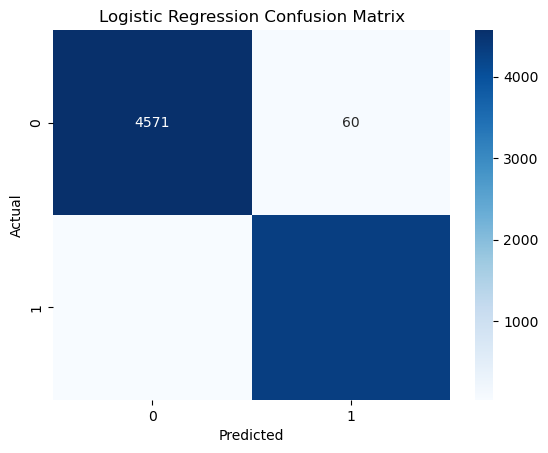

In [206]:
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [207]:
pickle.dump(lr_model, open("../models/logistic_regression_model.pkl", "wb"))

In [208]:
results = pd.DataFrame({
    "Model": ["Naive Bayes", "Decision Tree", "Logistic Regression"],
    "Accuracy": [accuracy, accuracy_dt, accuracy_lr]
})

results

,Model,Accuracy
0,Naive Bayes,0.936414
1,Decision Tree,0.996548
2,Logistic Regression,0.989198


In [209]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4631
           1       1.00      1.00      1.00      4349

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



In [210]:
def predict_news(text):

    cleaned = clean_text(text)

    vector = vectorizer.transform([cleaned])

    prediction = dt_model.predict(vector)

    if prediction == 0:
        print("Fake News")
    else:
        print("Real News")

In [211]:
predict_news("Government announces new economic policy")

Fake News


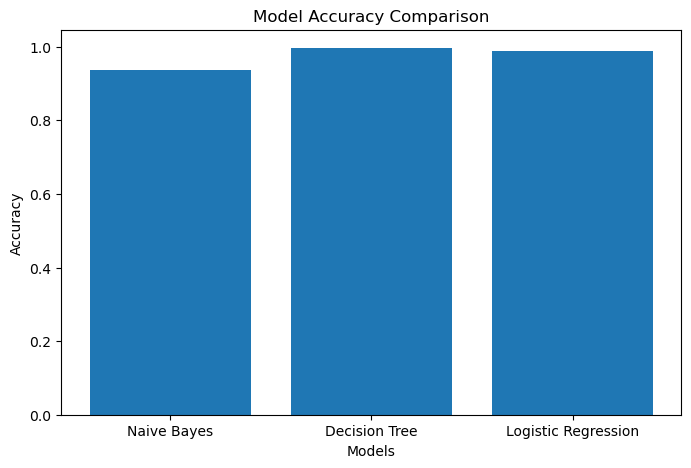

In [212]:
import matplotlib.pyplot as plt

models = ["Naive Bayes", "Decision Tree", "Logistic Regression"]
accuracies = [accuracy, accuracy_dt, accuracy_lr]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

In [213]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\Princy
[nltk_data]     Priya\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [214]:
sample = "Government announces new economic policy"

clean = clean_text(sample)

vec = vectorizer.transform([clean])

dt_model.predict(vec)

array([0], dtype=int64)